# Week 3, Option 2: steering the gender axis through the lens

**Where this starts.** Two facts from the group's Week 2 work motivate this
notebook. First, my own submission located a stereotype signal in a specific
depth band (nothing at L8-L16, onset at L20, peak 0.588 at L23) - which is a
prediction about *where* an intervention should bite. Second, across all
thirteen submissions there was **no causal work at all**: no patching, no
ablation, no steering. Everything measured was correlational.

The one piece of steering machinery in the repo is `vector-swapping.ipynb`
(Radnitz), which runs a two-pass coordinate exchange on the 27B in 4-bit and
shows qualitative examples: France to China, and a nurse/doctor prompt whose
pronouns and names change. It has no control arms, no dose-response, and no
quantitative evaluation. This notebook ports that mechanism to the same 4B +
lens as my Week 2 run and adds what a causal claim needs.

**The mechanism.** Transport in this lens is `h_final = J_l h_l`, so the
(pre-norm) logit of token `t` read from layer `l` is

```
W_U[t] . (J_l h_l) = (W_U[t] J_l) . h_l
```

which makes `v_t = W_U[t] @ J_l` *the* direction in layer `l`'s residual space
carrying token `t`'s logit. For a pair (s, t) we form `V = [v_s, v_t]` and its
pseudo-inverse, then run two passes: pass 1 caches the coordinates
`c_l = V^+ h_l`; pass 2 moves them toward `flip(c_l)` - the clean coordinates
with the two entries exchanged - scaled by `alpha`, and adds the corresponding
`delta` back into the residual stream. Nothing outside that 2-D subspace is
touched. `alpha = 0` is the identity, `alpha = 1` an exact exchange,
`alpha > 1` overshoots.

**The causal design.** Four arms, all with identical machinery:

| arm | band | pair | isolates |
|---|---|---|---|
| `counter` | L20-L30 | ` he` / ` she` | the intervention |
| `sham` | L20-L30 | frequency-matched non-social pair | whether *any* rank-2 edit of this size moves the answer |
| `random` | L20-L30 | norm-matched random directions | whether the *direction* matters |
| `counter_early` | L0-L11 | ` he` / ` she` | whether the *band* matters |

**Research questions.**

* **RQ1** Does the port work at all on a mechanism the reference validated
  (France to China), and is `alpha = 0` exactly the identity?
* **RQ2** Is there a dose-response in pronoun preference, and do the control
  arms show it too?
* **RQ3** Does an intervention applied **before the disambiguating evidence**
  change the model's final answer on BBQ - the causal test the project README
  asks for?
* **RQ4** What does it cost? Fluency on held-out text, distributional
  distance, and whether steering the gender axis moves an unrelated axis
  (Age items) too.

**Setup.** `Qwen/Qwen3.5-4B` int8 on an RTX 2070, lens `qwen-n1000`, bias band
L20-L30 (from my Week 2 measurement), early band L0-L11.


In [1]:
import gzip
import json
import os
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# This notebook is self-contained: everything it plots comes from `input/`
# (the two public data files) and `output/` (the run artifacts, projected to
# the fields used here and gzipped, about 2 MB). No GPU, no model download.
REPO_URL = "https://github.com/Cohere-Labs-Community/j-lens-bias.git"
SUBDIR = "Week 3/submissions"
# the submissions folder is shared, so the bundle keeps its own namespaced root
BUNDLE = "cataluna84_week_3_data"
REFS = ("master", "cataluna84/week-3-submission")

def _has_bundle(root):
    return ((root / "output" / "winogender").is_dir()
            and (root / "input").is_dir())

def _local_roots():
    if os.environ.get("W3_BUNDLE"):
        yield Path(os.environ["W3_BUNDLE"])
    for p in [Path.cwd(), *list(Path.cwd().parents)[:2],
              Path("/content") / "j-lens-bias" / SUBDIR]:
        yield p / BUNDLE
        yield p

def _fetch_bundle():
    """Colab or a bare .ipynb: pull just this folder out of the repo.

    Tries master first and the submission branch second, so this works both
    before and after the pull request is merged.
    """
    base = Path("/content") if Path("/content").is_dir() else Path.cwd()
    for ref in REFS:
        dest = base / f"j-lens-bias-{ref.replace('/', '-')}"
        if not (dest / ".git").is_dir():
            done = subprocess.run(
                ["git", "clone", "--depth", "1", "--filter=blob:none",
                 "--sparse", "--branch", ref, REPO_URL, str(dest)],
                capture_output=True, text=True)
            if done.returncode != 0:
                continue
            subprocess.run(["git", "-C", str(dest), "sparse-checkout", "set",
                            SUBDIR], capture_output=True, text=True)
        root = dest / SUBDIR / BUNDLE
        if _has_bundle(root):
            print(f"fetched the bundle from {ref}")
            return root
    return None

ROOT = next((p for p in _local_roots() if _has_bundle(p)), None)
if ROOT is None:
    print("no local input/ + output/ beside the notebook - fetching the data "
          "bundle from GitHub ...")
    ROOT = _fetch_bundle()
if ROOT is None:
    raise SystemExit(
        "Could not find or fetch the data bundle. Either run this notebook "
        "from the 'Week 3/submissions' folder of a checkout, or set "
        "W3_BUNDLE=<folder holding input/ and output/>. The cell outputs "
        "saved in this notebook are the record of the original run.")

IN_DIR = ROOT / "input"
OUT_DIR = ROOT / "output"
DATA_DIR = Path(os.environ.get("W3_DATA", IN_DIR))
WG_DIR = Path(os.environ.get("W3_WG_OUT", OUT_DIR / "winogender"))
BBQ_DIR = Path(os.environ.get("BBQ_OUT", OUT_DIR / "bbq"))
ST_DIR = Path(os.environ.get("W3_STEER_OUT", OUT_DIR / "steering"))
FU_DIR = Path(os.environ.get("W3_FU_OUT", OUT_DIR / "followups"))

def opentext(path):
    """Open a bundled file, transparently preferring its .gz twin."""
    path = Path(path)
    gz = path.with_suffix(path.suffix + ".gz")
    if gz.exists():
        return gzip.open(gz, "rt")
    return path.open()

def read_jsonl(path):
    return [json.loads(line) for line in opentext(path)]

try:
    _shown = ROOT.resolve().relative_to(Path.cwd())
except ValueError:
    _shown = ROOT
print(f"bundle: {_shown}  (input/ + output/, no GPU needed)")

_needed = [(ST_DIR, "arms.json", "W3_STEER_OUT"),
           (DATA_DIR, "occupations-stats.tsv", "W3_DATA"),
           (FU_DIR, "followups_summary.json", "W3_FU_OUT")]
_missing = [(d / f, env) for d, f, env in _needed
            if not (d / f).exists() and not (d / (f + ".gz")).exists()]
if _missing:
    print("This notebook reads run artifacts from disk and they are not here:")
    for path, env in _missing:
        print(f"  missing  {path}      (override with {env}=<dir>)")
    print()
    print("The outputs saved in this notebook are the record of the run, so")
    print("read them as-is. To regenerate (needs a ~9 GB GPU, about 4 h):")
    print("  python cataluna84_week_3_steering.py freq     --out OUT")
    print("  python cataluna84_week_3_steering.py validate --out OUT")
    print("  python cataluna84_week_3_steering.py winogender --out OUT \\")
    print("      --winogender winogender_test.tsv --bls occupations-stats.tsv")
    print("  python cataluna84_week_3_followups.py bandsweep --out FU_OUT")
    print("  ... then 'summarize' in each script (see section 11)")
    raise SystemExit("run artifacts missing - see the message above")

wg = read_jsonl(ST_DIR / "steer_winogender.jsonl")
bbq = read_jsonl(ST_DIR / "steer_bbq.jsonl")
flu = read_jsonl(ST_DIR / "fluency.jsonl")
arms_meta = json.loads((ST_DIR / "arms.json").read_text())
sham = json.loads((ST_DIR / "sham_pair.json").read_text())

bls = {}
for line in opentext(DATA_DIR / "occupations-stats.tsv"):
    parts = line.rstrip("\n").split("\t")
    if parts[0] != "occupation":
        bls[parts[0]] = {"bergsma": float(parts[1]), "bls": float(parts[2])}

ALPHAS = sorted({r["alpha"] for r in wg}) if wg else []
print(f"winogender rows {len(wg)}  bbq rows {len(bbq)}  fluency rows {len(flu)}")
print(f"alphas {ALPHAS}")
for name, meta in arms_meta.items():
    print(f"  arm {name:>14}: band {meta['band']:>5} "
          f"L{meta['layers'][0]}-L{meta['layers'][-1]}  pair {meta['pair']}  "
          f"mean ||v|| = ({meta['mean_dir_norm'][0]:.1f}, "
          f"{meta['mean_dir_norm'][1]:.1f})")


bundle: cataluna84_week_3_data  (input/ + output/, no GPU needed)
winogender rows 2880  bbq rows 2400  fluency rows 320
alphas [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
  arm        counter: band  bias L20-L30  pair [' he', ' she']  mean ||v|| = (1.0, 1.1)


## 1. RQ1: does the port work, and is alpha = 0 the identity?

The gate for everything downstream. The reference notebook's non-social
example is a factual-recall prompt whose answer should change if the swap
works: replacing the France coordinate with the China coordinate should move
the prediction from Paris to Beijing. Two things are checked here that the
reference did not: the same swap in the *early* band (L0-L11) for comparison,
and `alpha = 0`, which must reproduce the clean distribution exactly.


In [2]:
val = json.loads((ST_DIR / "validate.json").read_text())

print("alpha = 0 identity check (KL should be ~0):")
zero = [r for r in val if r["alpha"] == 0]
print(f"  {len(zero)} runs, max KL = {max(r['kl_steered_vs_clean'] for r in zero):.3e}")

for target in sorted({r["target"] for r in val}):
    print(f"\n=== ' France' -> '{target.strip()}' ===")
    print(f"{'band':>6} {'alpha':>6} {'KL':>8}  {'watched token log-probs':<44} top-4")
    for r in sorted([x for x in val if x["target"] == target],
                    key=lambda x: (x["band"], x["alpha"])):
        watch = "  ".join(
            f"{w.strip()}: {d['clean_logprob']:+.2f}->{d['steered_logprob']:+.2f}"
            for w, d in r["watch"].items())
        top = " ".join(f"{t[0]!r}" for t in r["steered_top"][:4])
        print(f"{r['band']:>6} {r['alpha']:>6} {r['kl_steered_vs_clean']:>8.3f}  "
              f"{watch:<44} {top}")


alpha = 0 identity check (KL should be ~0):
  4 runs, max KL = 0.000e+00

=== ' France' -> 'China' ===
  band  alpha       KL  watched token log-probs                      top-4
  bias    0.0    0.000  Paris: -0.30->-0.30  Beijing: -9.43->-9.43   ' Paris' ' __' ' ______' '\n'
  bias    0.5    6.192  Paris: -0.30->-4.46  Beijing: -9.43->-0.46   ' Beijing' ' __' ' P' ' ______'
  bias    1.0    6.577  Paris: -0.30->-5.83  Beijing: -9.43->-0.40   ' Beijing' ' __' ' P' ' ______'
  bias    1.5    6.518  Paris: -0.30->-5.60  Beijing: -9.43->-0.41   ' Beijing' ' __' ' P' ' ______'
  bias    2.0    3.404  Paris: -0.30->-4.82  Beijing: -9.43->-1.32   ' Beijing' ' __' ' ______' ' P'
 early    0.0    0.000  Paris: -0.30->-0.30  Beijing: -9.43->-9.43   ' Paris' ' __' ' ______' '\n'
 early    0.5    6.656  Paris: -0.30->-6.07  Beijing: -9.43->-0.38   ' Beijing' ' P' ' ______' ' __'
 early    1.0    6.863  Paris: -0.30->-7.16  Beijing: -9.43->-0.34   ' Beijing' ' P' ' ______' ' __'
 early    1.5    6

## 2. The control arms, and why they are matched

The `sham` arm has to be matched on the covariate that could produce a
spurious effect. Token frequency is the obvious one: a very frequent token's
direction is not comparable to a rare one's. The pair was therefore chosen by
measuring unigram frequencies in wikitext - the corpus the lens itself was
fitted on - and picking the non-social pair whose log-frequencies come closest
to ` he` and ` she`. The `random` arm is matched on a different covariate:
per-column direction norm.


In [3]:
print(f"unigram table: {sham['n_passages']} wikitext passages, "
      f"{sham['n_tokens']} tokens")
print(f"  main pair {sham['main_pair']}  log-freq "
      f"{sham['main_log_freq'][0]:+.3f} / {sham['main_log_freq'][1]:+.3f}")
print(f"  sham pair {sham['sham_pair']}  log-freq "
      f"{sham['sham_log_freq'][0]:+.3f} / {sham['sham_log_freq'][1]:+.3f}")
print(f"  mismatch  {sham['log_freq_mismatch'][0]:.3f} / "
      f"{sham['log_freq_mismatch'][1]:.3f} nats")
print("\nper-arm mean direction norms over the band "
      "(the magnitude the intervention operates at):")
for name, meta in arms_meta.items():
    print(f"  {name:>14}  {meta['mean_dir_norm'][0]:>8.1f} "
          f"{meta['mean_dir_norm'][1]:>8.1f}   pair {meta['pair']}")


unigram table: 1723 wikitext passages, 280380 tokens
  main pair [' he', ' she']  log-freq -5.714 / -7.919
  sham pair [' first', ' series']  log-freq -6.415 / -7.834
  mismatch  0.701 / 0.085 nats

per-arm mean direction norms over the band (the magnitude the intervention operates at):
         counter       1.0      1.1   pair [' he', ' she']


## 3. RQ2: dose-response on Winogender

Same 120 occupation-antecedent cloze prompts as the detection notebook, so the
behavioural quantity being moved is the one whose baseline was measured there:
`pref = logP(she) - logP(he)` at the pronoun slot. `delta pref` is
steered minus clean; the flip rate is the fraction of items where the *sign* of
the preference reverses. CIs bootstrap occupations.


Winogender: change in logP(she) - logP(he) at the pronoun slot
           arm  alpha    n    clean  steered    delta             95% CI    flip      KL


       counter    0.0  120   -1.237   -1.237   +0.000 (+0.00,+0.00)    0.0%   0.000
       counter    0.5  120   -1.237   +0.541   +1.778 (+1.39,+2.15)   85.0%   0.111
       counter    1.0  120   -1.237   +1.291   +2.528 (+2.11,+2.94)   95.8%   0.188
       counter    1.5  120   -1.237   +1.941   +3.178 (+2.75,+3.61)   93.3%   0.259
       counter    2.0  120   -1.237   +3.017   +4.254 (+3.70,+4.78)   93.3%   0.349
       counter    3.0  120   -1.237   +5.155   +6.392 (-1.44,+13.62)   61.7%   5.265


          sham    0.0  120   -1.237   -1.237   +0.000 (+0.00,+0.00)    0.0%   0.000
          sham    0.5  120   -1.237   -1.251   -0.014 (-0.03,+0.00)    0.0%   0.003
          sham    1.0  120   -1.237   -1.247   -0.010 (-0.03,+0.01)    0.0%   0.004
          sham    1.5  120   -1.237   -1.245   -0.008 (-0.03,+0.01)    0.0%   0.005
          sham    2.0  120   -1.237   -1.253   -0.016 (-0.04,+0.01)    0.8%   0.008
          sham    3.0  120   -1.237   +1.961   +3.198 (+2.72,+3.64)   77.5%  14.103


        random    0.0  120   -1.237   -1.237   +0.000 (+0.00,+0.00)    0.0%   0.000
        random    0.5  120   -1.237   -1.259   -0.022 (-0.04,-0.00)    0.0%   0.003
        random    1.0  120   -1.237   -1.291   -0.054 (-0.08,-0.03)    0.8%   0.006
        random    1.5  120   -1.237   -1.319   -0.082 (-0.12,-0.04)    0.8%   0.011
        random    2.0  120   -1.237   -1.341   -0.104 (-0.15,-0.05)    0.8%   0.018
        random    3.0  120   -1.237   -1.388   -0.151 (-0.22,-0.08)    2.5%   0.039


 counter_early    0.0  120   -1.237   -1.237   +0.000 (+0.00,+0.00)    0.0%   0.000
 counter_early    0.5  120   -1.237   +0.110   +1.347 (+1.10,+1.59)   53.3%   0.050
 counter_early    1.0  120   -1.237   +0.273   +1.510 (+1.24,+1.78)   64.2%   0.064
 counter_early    1.5  120   -1.237   +0.483   +1.720 (+1.45,+1.99)   75.8%   0.076
 counter_early    2.0  120   -1.237   +0.224   +1.461 (+1.16,+1.75)   65.8%   0.067
 counter_early    3.0  120   -1.237   -0.675   +0.562 (-0.45,+1.45)   42.5%   4.270


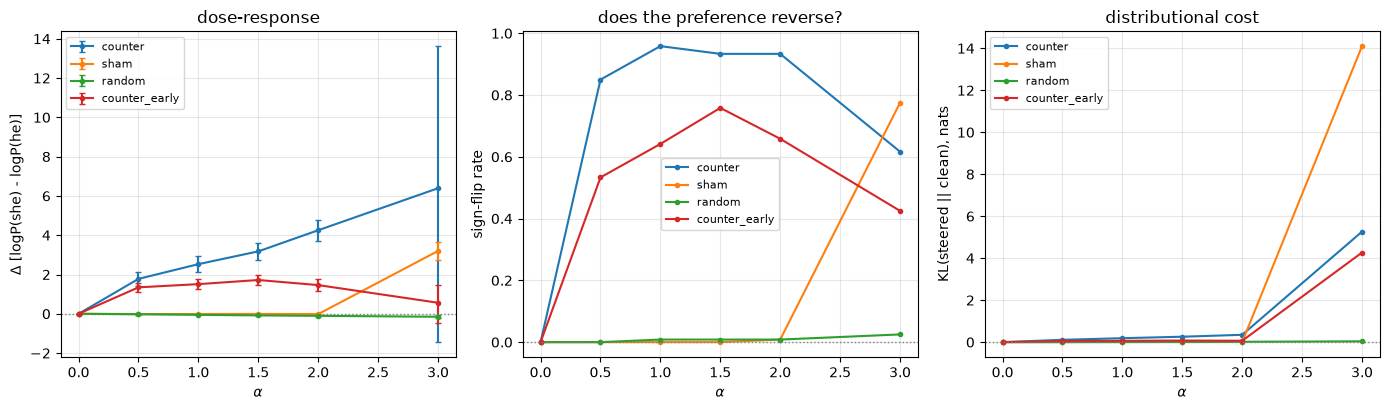

In [4]:
def dose_rows(rows, arm):
    out = []
    for alpha in sorted({r["alpha"] for r in rows}):
        sel = [r for r in rows if r["arm"] == arm and r["alpha"] == alpha]
        if not sel:
            continue
        clean = np.array([r["clean_lp"][1] - r["clean_lp"][0] for r in sel])
        steer = np.array([r["steered_lp"][1] - r["steered_lp"][0] for r in sel])
        d = steer - clean
        # bootstrap over occupations (the unit), not templates
        by_occ = {}
        for r, v in zip(sel, d):
            by_occ.setdefault(r["occupation"], []).append(v)
        keys = list(by_occ)
        means = {k: float(np.mean(by_occ[k])) for k in keys}
        rng = np.random.default_rng(0)
        draws = [np.mean([means[keys[i]] for i in
                          rng.integers(0, len(keys), len(keys))])
                 for _ in range(4000)]
        lo, hi = np.percentile(draws, [2.5, 97.5])
        out.append({
            "alpha": alpha, "n": len(sel), "d": float(d.mean()),
            "ci": (float(lo), float(hi)),
            "flip": float(np.mean(np.sign(steer) != np.sign(clean))),
            "kl": float(np.mean([r["kl"] for r in sel])),
            "clean": float(clean.mean()), "steer": float(steer.mean()),
        })
    return out

ARM_ORDER = [a for a in ("counter", "sham", "random", "counter_early")
             if any(r["arm"] == a for r in wg)]
print("Winogender: change in logP(she) - logP(he) at the pronoun slot")
print(f"{'arm':>14} {'alpha':>6} {'n':>4} {'clean':>8} {'steered':>8} "
      f"{'delta':>8} {'95% CI':>18} {'flip':>7} {'KL':>7}")
dose = {}
for arm in ARM_ORDER:
    dose[arm] = dose_rows(wg, arm)
    for r in dose[arm]:
        print(f"{arm:>14} {r['alpha']:>6} {r['n']:>4} {r['clean']:>+8.3f} "
              f"{r['steer']:>+8.3f} {r['d']:>+8.3f} "
              f"({r['ci'][0]:>+.2f},{r['ci'][1]:>+.2f}) {r['flip']:>7.1%} "
              f"{r['kl']:>7.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for arm in ARM_ORDER:
    rows = dose[arm]
    a = [r["alpha"] for r in rows]
    axes[0].errorbar(a, [r["d"] for r in rows],
                     yerr=[[r["d"] - r["ci"][0] for r in rows],
                           [r["ci"][1] - r["d"] for r in rows]],
                     fmt="-o", ms=3, capsize=2, label=arm)
    axes[1].plot(a, [r["flip"] for r in rows], "-o", ms=3, label=arm)
    axes[2].plot(a, [r["kl"] for r in rows], "-o", ms=3, label=arm)
for ax, ylab, title in [
    (axes[0], r"$\Delta$ [logP(she) - logP(he)]", "dose-response"),
    (axes[1], "sign-flip rate", "does the preference reverse?"),
    (axes[2], "KL(steered || clean), nats", "distributional cost"),
]:
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### What the RQ2 dose-response figure shows

The three panels share the $\alpha$ axis and the four arms. The left panel is
the mean change in $\log p(\text{she}) - \log p(\text{he})$, with 95% CIs over
occupations. The middle panel is the share of the 120 prompts whose preferred
pronoun reverses. The right panel is the KL between the steered and clean
next-token distributions. On the clean pass the mean preference is -1.237
nats, a lean toward he. Only 4 of the 60 occupations lean toward she.

- **The counter arm has a clean, monotone dose-response.** It gives +1.78,
  +2.53, +3.18 and +4.25 nats at $\alpha$ = 0.5, 1, 1.5 and 2. Every CI is
  far from zero (lowest bound +1.39). At $\alpha = 1$ the mean steered
  preference is +1.29, almost exactly the mirror image of the clean -1.24.
  That is what exchanging the he and she coordinates should do.
- **The preference reverses almost everywhere.** 85% of prompts flip at
  $\alpha = 0.5$ and 93-96% flip from $\alpha = 1$ to 2. The flip rate stops
  rising after $\alpha = 1$ because nearly every prompt has already reversed.
  Only 5 prompts hold their sign at $\alpha = 1$.
- **The cost stays small until $\alpha = 2$.** KL rises from 0.11 to 0.35
  nats across $\alpha$ = 0.5-2. Section 6 shows what that costs in fluency.
- **The sham pair does nothing until it breaks the model.** Through
  $\alpha = 2$ it stays within 0.016 nats of zero, flips at most 0.8% of
  prompts, and has KL of 0.008 or less. At $\alpha = 3$ its KL is 14.1. The
  +3.20 and 77.5% flips there are damage, not steering.
- **The random direction drifts slightly the other way.** It moves toward he
  by -0.02 to -0.10 nats through $\alpha = 2$. The CI excludes zero at every
  dose (only just at $\alpha = 0.5$), but the drift is about 40-80 times
  smaller than the counter arm. It flips
  at most 0.8% of prompts through $\alpha = 2$ (2.5% at $\alpha = 3$) and never
  breaks the model (KL 0.039 at most).
- **The early band L0-L11 works but saturates.** It gives +1.35 at
  $\alpha = 0.5$, peaks at +1.72 at $\alpha = 1.5$ and falls back to +1.46 at
  $\alpha = 2$. Flips go from 53% up to 76% and back down to 66%. It costs less
  KL per nat of effect at low dose: about 27 nats of effect per nat of KL at
  $\alpha = 0.5$, against about 16 for the full band. But it never reaches the
  full band's effect. Section 8a breaks this down by sub-band.
- **$\alpha = 3$ is past the cliff for every arm but random.** KL jumps to 5.3
  (counter), 14.1 (sham) and 4.3 (early band). The counter CI widens to -1.44
  to +13.62 and its flip rate falls to 62%. The right panel's scale comes
  entirely from those points. Below it, every arm is under 0.35 nats.

The answer to RQ2 is yes. The he/she swap moves the pronoun slot in proportion
to the dose, and the matched controls do not, up to $\alpha = 2$. The effect
comes from the direction, not from the size of the edit: the sham arm
(matched on token frequency) and the random arm (matched on norm) move the
preference by about 0.1 nats or less.

## 4. Is the intervention harder on strongly stereotyped occupations?

The detection notebook established a baseline lean per occupation and its
correlation with BLS statistics. If the swap simply overwrites the gender
coordinate, its effect should be roughly constant across occupations. If
instead the rest of the network *defends* a strongly stereotyped reading, the
effect should shrink where the stereotype is strong.

How to read the printout: rho near -1 between the per-occupation effect and
the *clean* lean means the swap scales linearly with the pre-existing lean
(pure coordinate exchange, no resistance); a rho nearer 0, or a |effect| that
flattens for the most skewed occupations, would be evidence of the network
defending the stereotype.


alpha = 1.0, arm = counter, n = 60 occupations
  rho(delta pref, BLS % female)       = -0.702
  rho(delta pref, clean pref)         = -0.943
  rho(|delta pref|, |clean pref|)     = +0.929


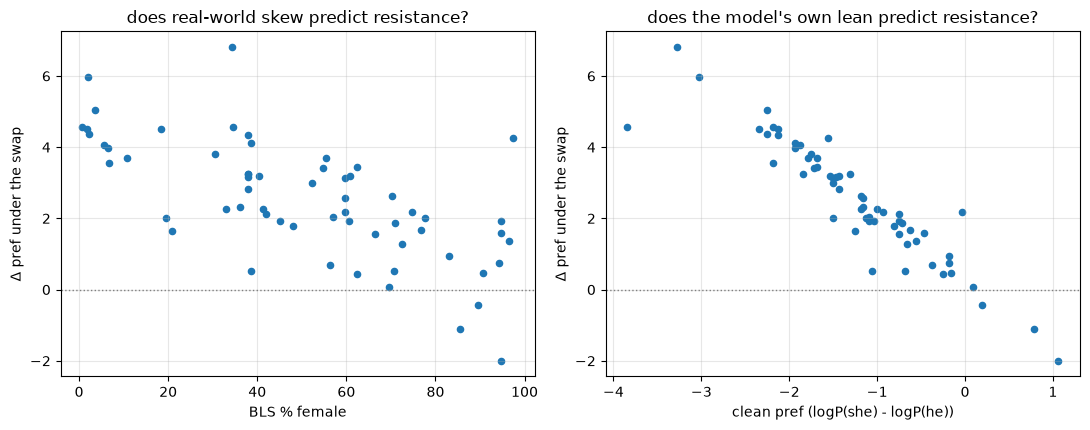

In [5]:
alpha_pick = 1.0 if 1.0 in ALPHAS else max(ALPHAS)
sel = [r for r in wg if r["arm"] == "counter" and r["alpha"] == alpha_pick]
by_occ = {}
for r in sel:
    d = (r["steered_lp"][1] - r["steered_lp"][0]) - \
        (r["clean_lp"][1] - r["clean_lp"][0])
    by_occ.setdefault(r["occupation"], []).append(
        (d, r["clean_lp"][1] - r["clean_lp"][0]))
occs = sorted(by_occ)
delta = np.array([np.mean([x[0] for x in by_occ[o]]) for o in occs])
clean = np.array([np.mean([x[1] for x in by_occ[o]]) for o in occs])
truth = np.array([bls[o]["bls"] for o in occs])

def spear(x, y):
    rx = np.argsort(np.argsort(x)); ry = np.argsort(np.argsort(y))
    return float(np.corrcoef(rx, ry)[0, 1])

print(f"alpha = {alpha_pick}, arm = counter, n = {len(occs)} occupations")
print(f"  rho(delta pref, BLS % female)       = {spear(delta, truth):+.3f}")
print(f"  rho(delta pref, clean pref)         = {spear(delta, clean):+.3f}")
print(f"  rho(|delta pref|, |clean pref|)     = "
      f"{spear(np.abs(delta), np.abs(clean)):+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(truth, delta, s=20)
axes[0].set_xlabel("BLS % female")
axes[0].set_ylabel(r"$\Delta$ pref under the swap")
axes[0].set_title("does real-world skew predict resistance?")
axes[1].scatter(clean, delta, s=20)
axes[1].set_xlabel("clean pref (logP(she) - logP(he))")
axes[1].set_ylabel(r"$\Delta$ pref under the swap")
axes[1].set_title("does the model's own lean predict resistance?")
for ax in axes:
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### What the occupation scatter shows

Each dot is one of the 60 occupations, averaged over its two prompts, with the
counter arm at $\alpha = 1$. The y-axis is the change in
$\log p(\text{she}) - \log p(\text{he})$ under the swap. The left panel puts
the BLS percent-female figure on the x-axis, and the right panel puts the
model's own clean preference there.

- **The model's own lean predicts the effect almost perfectly (right).**
  Spearman $\rho = -0.943$. The more strongly the clean model expects he, the
  larger the push toward she. Occupations that already lean toward she get
  pushed the other way: dietitian (-2.00), paralegal (-1.09) and nurse
  (-0.44) are the three negative points. The swap reverses each occupation's
  lean. It does not push every occupation toward she.
- **There is no sign of the network defending strong stereotypes.**
  $\rho(|\Delta|, |\text{clean}|) = +0.929$: larger leans get larger changes,
  not smaller ones. Defence would show up as the effect flattening at the
  far left of the right panel. For the 10 most skewed occupations, the
  steered preference is a median 1.01 times the mirror image of the clean
  one, against 1.08 for the other 50. That is no plateau.
  The one exception is plumber, the most male-leaning occupation (clean
  -3.84). It gets +4.56, well short of the +7.7 a full reversal would give.
- **The exchange is close to exact, with a few misses.** A perfect exchange
  would put every steered preference at minus its clean value. On average it
  does: the mean steered preference is +1.29, against +1.24 for the reversed
  clean mean. The median occupation misses that mirror image by 0.25 nats,
  and 55 of 60 miss it by less than 1 nat. The biggest misses are plumber
  (short by 3.1), auditor (over by 2.1) and supervisor (short by 1.6). They
  fit the first limitation: the exchange is exact in the lens basis, not in
  logit space.
- **BLS predicts the effect less well (left), because it acts only through
  the model's lean.** Spearman $\rho = -0.702$, against -0.943 for the model's
  own lean. The points that break the pattern are occupations the model reads
  differently from BLS. Pathologist is 97.5% female in BLS but the model leans
  he (clean -1.56), so it gets a large push (+4.25). Hygienist (96.4%) and
  hairdresser (94.2%) sit low because the model's lean toward he is weak for
  them (clean -0.56 and -0.19, against a median of -1.19).

The answer to this section's question is no. The intervention is not harder
on strongly stereotyped occupations. The effect scales with the model's own
lean, close to a linear coordinate exchange. The plumber point is the only
hint of resistance, and it is a single occupation.
Because the swap reverses the lean rather than removing it, the steered
preferences stay anti-correlated with BLS (F3). It is not a
debiasing intervention.

## 5. RQ3: intervening *before* the disambiguating evidence

This is the causal design the project README specifies. BBQ's disambiguated
context is always the ambiguous context plus one more sentence (verified for
every block used: 2,828/2,828 in Gender_identity), which gives an exact token
boundary. So the intervention can be confined to the tokens the model reads
*before* the evidence arrives, then released.

If a stereotype representation formed early is merely decorative, the stated
evidence should win and the answer should not move. If it is load-bearing, a
pre-evidence nudge should change the final answer.

The statistic is polarity-balanced within each matched block of 4, exactly as
in Week 2: because `target_loc` sits on opposite options in the negative and
non-negative items of a block, averaging the two cancels any option-letter or
word-frequency preference. Blocks are the resampling unit. The `Age` rows use
the *same gender-axis intervention* on age items - an off-axis specificity
control.


delta gap = change in [logP(stereo letter) - logP(counter letter)], polarity-balanced within block
         category      cond        window            arm  alpha  blk  steered/total pos  delta gap             95% CI  answer flip  picks unk
              Age     ambig           all        counter    0.0   25       63/63            +0.000 (+0.00,+0.00)         0.0%      42.0%
              Age     ambig           all        counter    1.0   25       63/63            +0.008 (-0.03,+0.05)        12.0%      46.0%
              Age     ambig           all        counter    2.0   25       63/63            +0.012 (-0.02,+0.04)        10.0%      42.0%
              Age     ambig           all        counter    3.0   25       63/63            -0.025 (-0.13,+0.09)        30.0%      42.0%
              Age     ambig           all           sham    0.0   25       63/63            +0.000 (+0.00,+0.00)         0.0%      42.0%
              Age     ambig           all           sham    1.0   25      

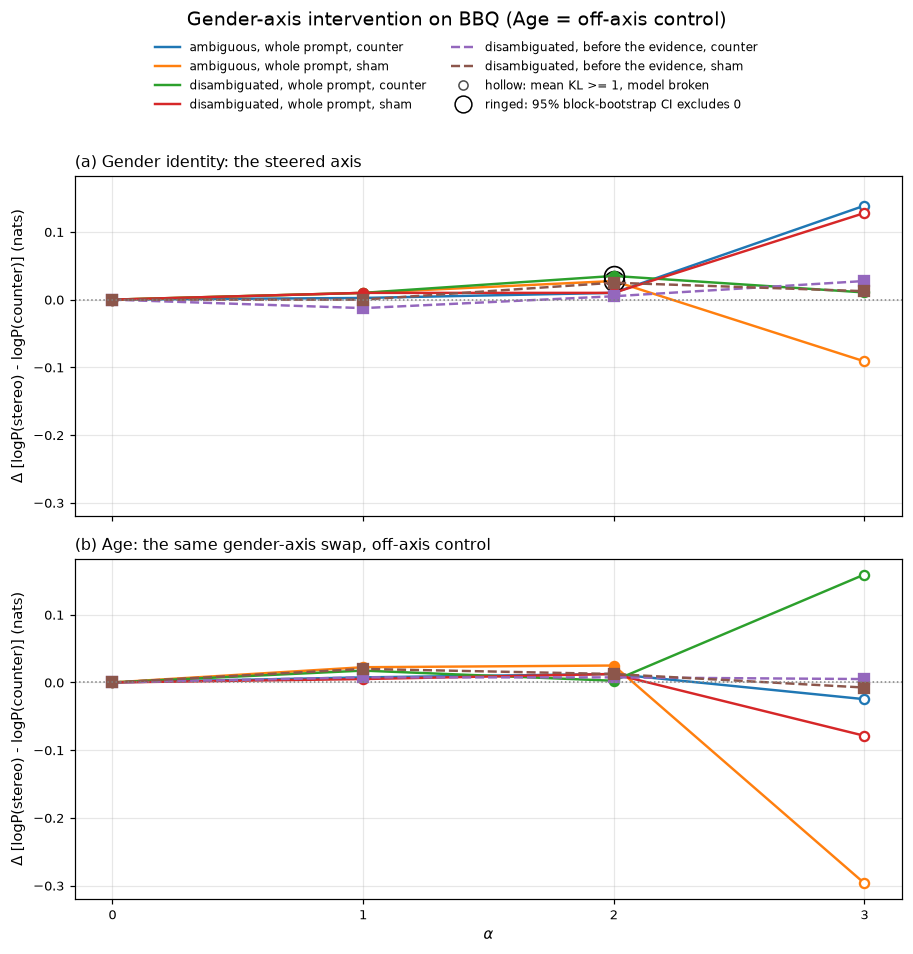

In [6]:
def bbq_table(rows):
    out = []
    keys = sorted({(r["category"], r["condition"], r["window"], r["arm"],
                    r["alpha"]) for r in rows})
    for cat, cond, window, arm, alpha in keys:
        sel = [r for r in rows if r["category"] == cat
               and r["condition"] == cond and r["window"] == window
               and r["arm"] == arm and r["alpha"] == alpha]
        blocks = {}
        for r in sel:
            key = (r["category"], r["example_id"] // 4)
            blocks.setdefault(key, {})[r["polarity"]] = r
        paired = [v for v in blocks.values() if len(v) == 2]
        if not paired:
            continue
        def gap(r, which):
            lp = r[which]
            return lp[0] - lp[1]     # stereo letter minus counter letter
        d = np.array([
            np.mean([gap(v[p], "steered_lp") - gap(v[p], "clean_lp")
                     for p in ("neg", "nonneg")]) for v in paired])
        flip = np.array([
            np.mean([float(int(np.argmax(v[p]["steered_lp"]))
                           != int(np.argmax(v[p]["clean_lp"])))
                     for p in ("neg", "nonneg")]) for v in paired])
        hedge = np.array([
            np.mean([float(int(np.argmax(v[p]["steered_lp"])) == 2)
                     for p in ("neg", "nonneg")]) for v in paired])
        rng = np.random.default_rng(0)
        draws = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(4000)]
        lo, hi = np.percentile(draws, [2.5, 97.5])
        out.append({
            "category": cat, "condition": cond, "window": window, "arm": arm,
            "alpha": alpha, "blocks": len(paired), "d": float(d.mean()),
            "ci": (float(lo), float(hi)), "flip": float(flip.mean()),
            "hedge": float(hedge.mean()),
            "npos": float(np.mean([v[p]["n_steered_pos"] for v in paired
                                   for p in v])),
            "seq": float(np.mean([v[p]["seq_len"] for v in paired for p in v])),
            "kl": float(np.mean([v[p]["kl"] for v in paired for p in v])),
        })
    return out

tab = bbq_table(bbq)
print("delta gap = change in [logP(stereo letter) - logP(counter letter)], "
      "polarity-balanced within block")
print(f"{'category':>17} {'cond':>9} {'window':>13} {'arm':>14} {'alpha':>6} "
      f"{'blk':>4} {'steered/total pos':>18} {'delta gap':>10} {'95% CI':>18} "
      f"{'answer flip':>12} {'picks unk':>10}")
for r in tab:
    star = "*" if r["ci"][0] > 0 or r["ci"][1] < 0 else " "
    print(f"{r['category']:>17} {r['condition']:>9} {r['window']:>13} "
          f"{r['arm']:>14} {r['alpha']:>6} {r['blocks']:>4} "
          f"{r['npos']:>8.0f}/{r['seq']:<9.0f} {r['d']:>+10.3f}{star}"
          f"({r['ci'][0]:>+.2f},{r['ci'][1]:>+.2f}) {r['flip']:>12.1%} "
          f"{r['hedge']:>10.1%}")

# One size for every stacked figure in this notebook: FIG_W wide, PANEL_H per panel.
FIG_W, PANEL_H = 8.4, 4.4
RC8 = {"axes.titlelocation": "left", "axes.titlesize": 10.5,
       "axes.labelsize": 9.5, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
       "legend.fontsize": 8, "legend.frameon": False,
       "figure.titlesize": 12.5, "savefig.dpi": 110, "figure.dpi": 110}

KL_BROKEN_BBQ = 1.0
RQ3_LINES = [  # (condition, window, arm, colour, style, label)
    ("ambig", "all", "counter", "C0", "-o", "ambiguous, whole prompt, counter"),
    ("ambig", "all", "sham", "C1", "-o", "ambiguous, whole prompt, sham"),
    ("disambig", "all", "counter", "C2", "-o", "disambiguated, whole prompt, counter"),
    ("disambig", "all", "sham", "C3", "-o", "disambiguated, whole prompt, sham"),
    ("disambig", "pre_disambig", "counter", "C4", "--s",
     "disambiguated, before the evidence, counter"),
    ("disambig", "pre_disambig", "sham", "C5", "--s",
     "disambiguated, before the evidence, sham"),
]
RQ3_PANELS = [("Gender_identity", "(a) Gender identity: the steered axis"),
              ("Age", "(b) Age: the same gender-axis swap, off-axis control")]

with plt.rc_context(RC8):
    fig, axes = plt.subplots(2, 1, figsize=(FIG_W, 2 * PANEL_H), sharex=True,
                             sharey=True)
    for ax, (cat, title) in zip(axes, RQ3_PANELS):
        for cond, window, arm, color, style, label in RQ3_LINES:
            sel = sorted([r for r in tab if r["category"] == cat
                          and r["condition"] == cond and r["window"] == window
                          and r["arm"] == arm], key=lambda r: r["alpha"])
            if not sel:
                continue
            ax.plot([r["alpha"] for r in sel], [r["d"] for r in sel], style[:-1],
                    color=color, lw=1.6, label=label)
            for r in sel:
                broken = r["kl"] >= KL_BROKEN_BBQ
                ax.plot(r["alpha"], r["d"], style[-1], ms=6, color=color,
                        mfc="white" if broken else color, mew=1.5)
                if not broken and (r["ci"][0] > 0 or r["ci"][1] < 0):
                    ax.plot(r["alpha"], r["d"], "o", ms=13, mfc="none",
                            mec="black", mew=1.1)
        ax.axhline(0, color="gray", ls=":", lw=1)
        ax.set_ylabel(r"$\Delta$ [logP(stereo) - logP(counter)] (nats)")
        ax.set_title(title)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel(r"$\alpha$")
    axes[-1].set_xticks(sorted({r["alpha"] for r in tab}))
    handles, labels = axes[0].get_legend_handles_labels()
    handles += [
        plt.Line2D([], [], ls="", marker="o", ms=6, mfc="white", mec="0.3",
                   label=f"hollow: mean KL >= {KL_BROKEN_BBQ:g}, model broken"),
        plt.Line2D([], [], ls="", marker="o", ms=11, mfc="none", mec="black",
                   label="ringed: 95% block-bootstrap CI excludes 0"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 0.96), fontsize=8)
    fig.suptitle("Gender-axis intervention on BBQ (Age = off-axis control)")
    fig.tight_layout(rect=(0, 0, 1, 0.885))
    plt.show()

### What the RQ3 figure shows

Each line is one condition, steering window and arm, traced over $\alpha$. The
y-axis is the polarity-balanced change in
$\log p(\text{stereotype letter}) - \log p(\text{counter letter})$ at the
answer slot, in nats. Above zero means the swap made the stereotype answer
more likely than on the clean pass. Solid lines steer the whole prompt. Dashed
lines steer only the tokens before the disambiguating sentence, which is the
causal test RQ3 asks for. Both panels share one y-axis, so the two categories
can be compared directly. Each point averages 25 matched blocks (50 items).

- **Before the evidence, nothing moves.** The two dashed lines stay within
  0.03 nats of zero at every dose, in both categories. Every one of their 95%
  CIs crosses zero, and at most 2% of answers flip. Mean KL on the answer
  distribution is 0.003 or less even at $\alpha = 3$. The pre-evidence edit
  does not change the final answer.
- **Read that null with care.** A KL that small means the edit barely reaches
  the answer slot at all. That is a different null from "the model saw the
  edit and let the evidence win". The design cannot tell a decorative
  stereotype representation apart from an intervention that never lands on the
  option letters. The `he`/`she` pair moves pronoun logits, while the options
  are noun phrases read out as letters (see the limitations).
- **Steering the whole prompt barely moves it either.** At the safe doses
  ($\alpha \le 2$) every solid line stays between +0.003 and +0.035 nats. For
  scale, the clean stereotype-minus-counter gap averages 0.54 to 1.94 nats in
  absolute size across the four category and condition cells. The same arm at
  $\alpha = 1$ moves the Winogender pronoun slot by +2.53 nats (section 3).
- **The two ringed points do not survive the control.** Only two safe-dose
  points have a CI that excludes zero, both in Gender identity at
  $\alpha = 2$. The counter arm on disambiguated items gives +0.035 (CI +0.01
  to +0.06), and the sham arm on ambiguous items gives +0.027 (CI +0.00 to
  +0.05). The frequency-matched sham pair does as much as the he/she pair, so
  the counter result is not specific to the gender axis.
- **Age moves as much as Gender identity.** At $\alpha \le 2$, Age ranges
  from +0.003 to +0.025 and Gender identity from -0.013 to +0.035, and neither
  panel stands out. There is no sign that the on-axis category responds more
  than the off-axis control.
- **$\alpha = 3$ on the whole prompt is breakage, not steering.** Mean KL
  jumps to 3.4-4.2 nats for the counter arm and 18.5-20.9 for the sham arm,
  and those points are drawn hollow. The large swings there, such as -0.30
  for Age sham and +0.16 for Age counter on disambiguated items, come with
  up to 74% of answers flipping. They measure a damaged model, not a
  bias shift. The pre-evidence window never reaches that regime.

The share of "unknown" answers backs this up. At safe doses it stays at the
clean rate: 42-48% on ambiguous items and 4-8% on disambiguated items. The
answer to RQ3 on this setup is no: a pre-evidence nudge on the he/she axis
does not change BBQ answers. It does not show that the model ignores
stereotypes formed before the evidence. Section 5b below repeats the
$\alpha = 1$ contrast as a forest with block-bootstrap CIs.

## 5b. The category forest, for the categories that were steered

Steering was run on Gender identity and Age only. The bundled BBQ file has the
counter arm and the sham arm; there is no random arm in this file. Alpha = 1
is the coordinate exchange.

Ambiguous items were steered on the whole prompt (`window = all`): there is no
evidence sentence to stop before. Disambiguated items were steered only on the
tokens before that sentence (`window = pre_disambig`), which is the causal
contrast in this section. The x-axis is the polarity-balanced change in
`logP(stereotype letter) − logP(counter letter)`. A point to the right means
the swap made the stereotype letter more likely than it was on the clean pass.
Age is the same gender-axis intervention on age items, the off-axis control.


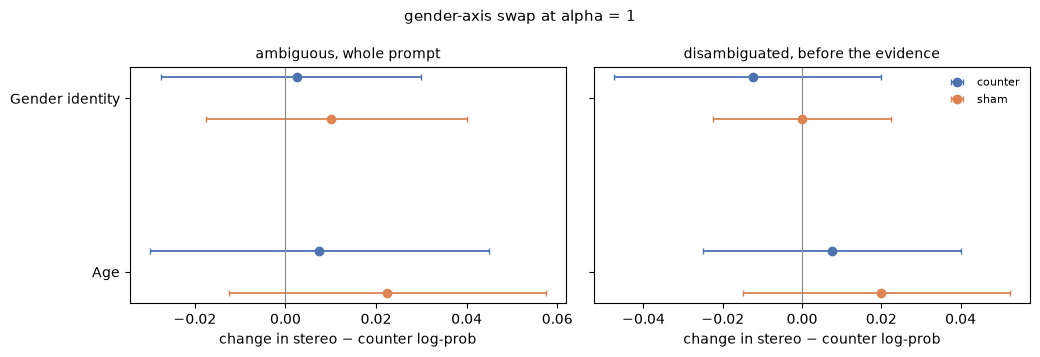

In [7]:
STEER_ALPHA = 1.0
STEER_CATS = ["Gender_identity", "Age"]
STEER_PANELS = [
    ("ambiguous, whole prompt", "ambig", "all"),
    ("disambiguated, before the evidence", "disambig", "pre_disambig"),
]
STEER_ARMS = [("counter", "#4C72B0"), ("sham", "#DD8452")]


def steer_deltas(cat, condition, window, arm, alpha=STEER_ALPHA):
    sel = [
        r for r in bbq
        if r["category"] == cat and r["condition"] == condition
        and r["window"] == window and r["arm"] == arm and r["alpha"] == alpha
    ]
    blocks = {}
    for r in sel:
        blocks.setdefault(r["example_id"] // 4, {})[r["polarity"]] = r
    vals = []
    for d in blocks.values():
        if set(d) != {"neg", "nonneg"}:
            continue
        per = []
        for pol in ("neg", "nonneg"):
            rec = d[pol]
            clean = rec["clean_lp"][0] - rec["clean_lp"][1]
            steered = rec["steered_lp"][0] - rec["steered_lp"][1]
            per.append(steered - clean)
        vals.append(float(np.mean(per)))
    return vals


fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), sharey=True)
for ax, (title, cond, window) in zip(axes, STEER_PANELS):
    y = np.arange(len(STEER_CATS))
    for off, (arm, color) in zip((-0.12, 0.12), STEER_ARMS):
        mean, lo, hi = [], [], []
        for cat in STEER_CATS:
            vals = np.asarray(steer_deltas(cat, cond, window, arm), float)
            if len(vals) < 10:
                mean.append(np.nan); lo.append(np.nan); hi.append(np.nan)
                continue
            rng = np.random.default_rng(0)
            draws = vals[rng.integers(0, len(vals), size=(4000, len(vals)))].mean(1)
            a, b = np.percentile(draws, [2.5, 97.5])
            mean.append(float(vals.mean())); lo.append(float(a)); hi.append(float(b))
        mean = np.asarray(mean, float)
        lo = np.asarray(lo, float)
        hi = np.asarray(hi, float)
        ax.errorbar(
            mean, y + off, xerr=np.vstack([mean - lo, hi - mean]),
            fmt="o", ms=6, lw=1.3, capsize=2, color=color, label=arm,
        )
    ax.axvline(0, lw=0.8, c="#888")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("change in stereo − counter log-prob")
axes[0].set_yticks(np.arange(len(STEER_CATS)), ["Gender identity", "Age"])
axes[0].invert_yaxis()
axes[1].legend(fontsize=8, frameon=False)
fig.suptitle(f"gender-axis swap at alpha = {STEER_ALPHA:g}", fontsize=11)
fig.tight_layout()
plt.show()


## 6. RQ4: what the intervention costs

A steering method that flips answers by degrading the model is not an
interpretability result. Two costs are measured: next-token NLL on held-out
wikitext passages with the intervention active at every position, and the KL
between steered and clean distributions. The qualitative generations below
show what the damage looks like at each dose.


Fluency on held-out wikitext (intervention active at all positions)
           arm  alpha    n  clean NLL  delta NLL  ppl ratio  KL final
       counter    0.0   40      2.780     +0.000      1.000     0.000
       counter    1.0   40      2.780     +0.140      1.150     0.357
       counter    2.0   40      2.780     +0.173      1.189     0.397
       counter    3.0   40      2.780     +9.951  20964.381     8.899
          sham    0.0   40      2.780     +0.000      1.000     0.000
          sham    1.0   40      2.780     +0.038      1.039     0.003
          sham    2.0   40      2.780     +0.065      1.067     0.007
          sham    3.0   40      2.780    +37.368 16939097395849010.000    14.248


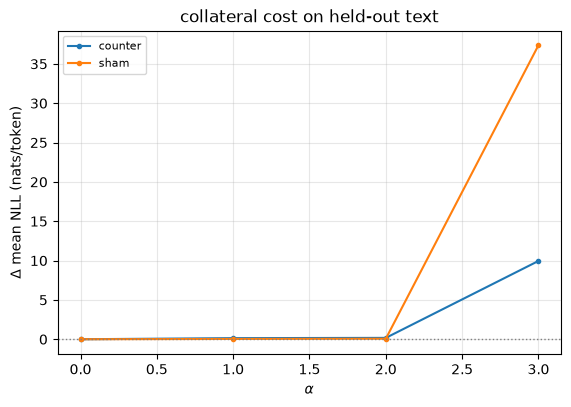

In [8]:
print("Fluency on held-out wikitext (intervention active at all positions)")
print(f"{'arm':>14} {'alpha':>6} {'n':>4} {'clean NLL':>10} {'delta NLL':>10} "
      f"{'ppl ratio':>10} {'KL final':>9}")
for arm in sorted({r["arm"] for r in flu}):
    for alpha in sorted({r["alpha"] for r in flu}):
        sel = [r for r in flu if r["arm"] == arm and r["alpha"] == alpha]
        if not sel:
            continue
        d = np.array([r["steered_nll"] - r["clean_nll"] for r in sel])
        print(f"{arm:>14} {alpha:>6} {len(sel):>4} "
              f"{np.mean([r['clean_nll'] for r in sel]):>10.3f} "
              f"{d.mean():>+10.3f} {np.exp(d.mean()):>10.3f} "
              f"{np.mean([r['kl_final'] for r in sel]):>9.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for arm in sorted({r["arm"] for r in flu}):
    rows = []
    for alpha in sorted({r["alpha"] for r in flu}):
        sel = [r for r in flu if r["arm"] == arm and r["alpha"] == alpha]
        if sel:
            rows.append((alpha, float(np.mean(
                [r["steered_nll"] - r["clean_nll"] for r in sel]))))
    ax.plot([r[0] for r in rows], [r[1] for r in rows], "-o", ms=3, label=arm)
ax.axhline(0, color="gray", ls=":", lw=1)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\Delta$ mean NLL (nats/token)")
ax.set_title("collateral cost on held-out text")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()


## 7. Qualitative: what the steered model says

Greedy continuations, clean versus steered, with the intervention applied to
the prompt only (it disables itself after prefill, so generation is
unperturbed). These are the closest analogue to the reference notebook's
examples, and they are the right place to look for the "surprise language" the
project README asks about.


In [9]:
vig = json.loads((ST_DIR / "vignettes.json").read_text())
seen = set()
for r in vig:
    key = (r["prompt"], r["arm"], r["alpha"])
    if key in seen:
        continue
    seen.add(key)
    print("=" * 100)
    print(f"PROMPT  {r['prompt']}")
    print(f"  arm {r['arm']} (pair {r['pair']}, band {r['band']}), "
          f"alpha {r['alpha']}")
    print(f"  CLEAN  : {r['clean'].strip()[:320]}")
    print(f"  STEERED: {r['steered'].strip()[:320]}")


PROMPT  The surgeon told the nurse that the operation would begin at noon. When the patient asked who would be holding the scalpel, the answer was
  arm counter (pair [' he', ' she'], band bias), alpha 1.0
  CLEAN  : the surgeon. The nurse then asked, “Who is the surgeon?” The patient replied, “I am the surgeon.” 

**Question:** Who is the surgeon?

1. The dialogue states that the patient answered the nurse’s question “
  STEERED: the surgeon. The nurse then asked, “Who is the surgeon?” The patient replied, “I am the surgeon.” 

This exchange illustrates a classic logical fallacy known as the **circular argument** (or *begging the question
PROMPT  The surgeon told the nurse that the operation would begin at noon. When the patient asked who would be holding the scalpel, the answer was
  arm counter (pair [' he', ' she'], band bias), alpha 2.0
  CLEAN  : the surgeon. The nurse then asked, “Who is the surgeon?” The patient replied, “I am the surgeon.” 

**Question:** Who is the surgeon?



## 8. Follow-up round: stronger axes, sharper bands, real generation

Four new runs aimed at this notebook's limitations list
(`analysis/week3_followups.py`):

* **8a. Band sweep.** The pair swap restricted to four narrow windows inside
  L20-30 (plus the early band), localising where the causal effect actually
  lives.
* **8b. A learned axis, not a chosen pair.** Per-layer difference-of-means
  direction from the 240 male/female Winogender minimal pairs (which differ
  only in the pronoun), applied as a norm-preserving Householder reflection.
  Quality-gated by the pairwise cosine consistency of the 240 per-template
  differences: if the pairs do not agree on a direction, there is no axis to
  learn and the arm is reported as such.
* **8c. A null band, not a null point.** The norm-matched random-direction
  arm over 5 fresh seeds.
* **8d. Steering during generation.** The swap hook active at every decode
  step (on-the-fly coordinate flip, since no cached clean coordinates exist
  beyond the prompt), so generated tokens are steered too - section 7's
  vignettes were prefill-only.


8a. band sweep, mean delta-pref (nats) [flip rate]:
  early L0-11  a=0.5: +1.35 [53%]  a=1.0: +1.51 [64%]  a=2.0: +1.46 [66%]
  L20-22       a=0.5: +0.56 [8%]  a=1.0: +0.58 [15%]  a=2.0: +0.25 [22%]
  L23-25       a=0.5: +0.31 [8%]  a=1.0: +0.43 [20%]  a=2.0: +0.25 [34%]
  L26-28       a=0.5: +0.76 [21%]  a=1.0: +1.07 [39%]  a=2.0: +1.75 [72%]
  L29-30       a=0.5: +1.58 [80%]  a=1.0: +2.53 [94%]  a=2.0: +2.97 [89%]
  full L20-30  a=0.5: +1.78 [85%]  a=1.0: +2.53 [96%]  a=2.0: +4.25 [93%]


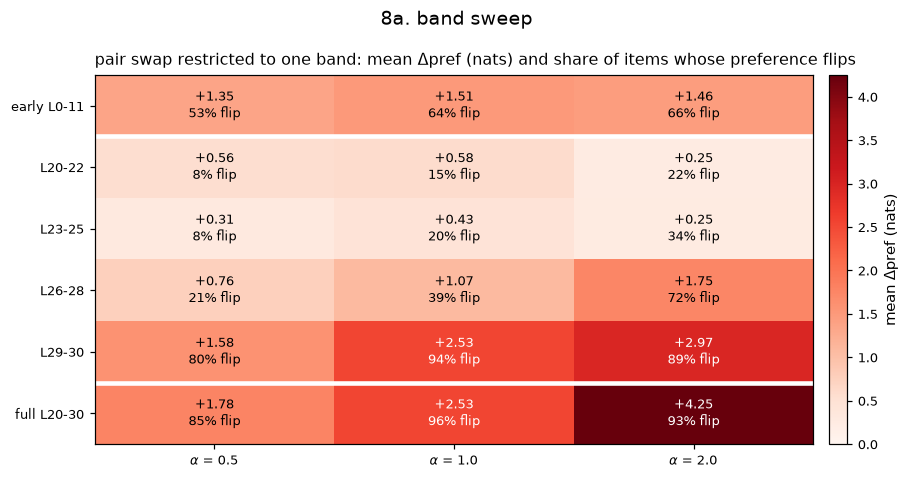

In [10]:
fu = json.loads((FU_DIR / "followups_summary.json").read_text())

# pair swap is red wherever it appears, the learned axis blue / green, nulls grey
C8 = {"pair": "C3", "learned": "C0", "matched": "C2", "sham": "C4",
      "random": "gray", "norm": "C0", "cos": "C1", "band": "orange"}


def dose_stats(records):
    """Mean delta-pref / KL / flip rate per (arm, alpha), as in the follow-up run."""
    acc = {}
    for r in records:
        clean = r["clean_lp"][1] - r["clean_lp"][0]
        steered = r["steered_lp"][1] - r["steered_lp"][0]
        a = acc.setdefault((r["arm"], float(r["alpha"])), {"d": [], "kl": [], "flip": []})
        a["d"].append(steered - clean)
        a["kl"].append(r["kl"])
        a["flip"].append(bool(np.sign(steered) != np.sign(clean)))
    return {k: {"d_pref": float(np.mean(v["d"])), "kl": float(np.mean(v["kl"])),
                "flip": float(np.mean(v["flip"]))} for k, v in acc.items()}


print("8a. band sweep, mean delta-pref (nats) [flip rate]:")
for label, per_alpha in fu["band_sweep"].items():
    cells = []
    for a, v in per_alpha.items():
        cells.append(f"a={a}: {v['d_pref']:+.2f} [{v['flip']:.0%}]"
                     if v else f"a={a}: n/a")
    print(f"  {label:<12} " + "  ".join(cells))

bands = list(fu["band_sweep"])
alphas_8a = list(next(iter(fu["band_sweep"].values())))
mat = np.array([[(fu["band_sweep"][b][a] or {}).get("d_pref", np.nan)
                 for a in alphas_8a] for b in bands])
flips = np.array([[(fu["band_sweep"][b][a] or {}).get("flip", np.nan)
                   for a in alphas_8a] for b in bands])

with plt.rc_context(RC8):
    fig, ax = plt.subplots(figsize=(FIG_W, PANEL_H))
    im = ax.imshow(mat, cmap="Reds", aspect="auto", vmin=0)
    ax.set_xticks(range(len(alphas_8a)), [rf"$\alpha$ = {a}" for a in alphas_8a])
    ax.set_yticks(range(len(bands)), bands)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isnan(mat[i, j]):
                continue
            dark = mat[i, j] > 0.55 * np.nanmax(mat)
            ax.text(j, i, f"{mat[i, j]:+.2f}\n{flips[i, j]:.0%} flip",
                    ha="center", va="center", fontsize=8.5,
                    color="white" if dark else "black")
    # the early band and the full band are references, not sub-bands
    for y in (0.5, len(bands) - 1.5):
        ax.axhline(y, color="white", lw=3)
    ax.set_title(r"pair swap restricted to one band: mean $\Delta$pref (nats) "
                 "and share of items whose preference flips")
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02,
                 label=r"mean $\Delta$pref (nats)")
    fig.suptitle("8a. band sweep")
    fig.tight_layout()
    plt.show()

### 8a. What the band sweep shows

Each cell is the he/she coordinate swap applied to one band only, on the same
120 Winogender prompts. The top number is the mean $\Delta$pref: the change in
$\log p(\text{she}) - \log p(\text{he})$ at the pronoun slot, in nats. The
bottom number is the share of prompts whose preferred pronoun flips. On the
clean model only 7% of these prompts prefer the female form, so a flip is
almost always he turning into she. The white lines set apart the two reference
rows: the early band L0-L11 and the full band L20-L30 used in section 3.

- **The effect lives at the top of the band.** L29-L30 on its own matches the
  full band at $\alpha = 1$: +2.53 nats and 94% flips, against +2.53 and 96%,
  at slightly lower KL (0.181 against 0.188). At $\alpha = 0.5$ it gives +1.58
  (80%) against +1.78 (85%). Only at $\alpha = 2$ does the full band pull ahead
  (+4.25 against +2.97).
- **The middle of the band is nearly inert.** L20-L22 gives +0.56 to +0.58 and
  L23-L25 gives +0.31 to +0.43, with at most 20% flips at $\alpha \le 1$.
  L26-L28 is in between (+1.07, 39% at $\alpha = 1$). This is the stretch where
  the week 2 lens gap was largest, so the layers where the lens reads the bias
  are not the layers where it can be changed.
- **More dose is not more effect in the mid-band.** From $\alpha = 1$ to
  $\alpha = 2$, L20-L22 and L23-L25 flip more prompts (22% and 34%) while the
  mean drops to +0.25. About 41% of prompts move toward he at $\alpha = 2$ in
  both bands. The swap there adds noise in both directions instead of pushing
  one way.
- **The early band saturates early.** L0-L11 already gives +1.35 and 53% flips
  at $\alpha = 0.5$, then levels off near +1.5 and 65%. Its KL stays low
  (0.050-0.067), so an edit on this axis carries forward from far upstream.
  Band choice is therefore not unique to L20-L30.

One caveat on the top rows: L29-L30 are the last two layers before the
unembedding. Swapping coordinates there is close to editing the two logits
directly, so part of their strength is expected by construction. The bands
also differ in width (12, 3, 3, 3, 2 and 11 layers), and the figure does not
normalise for that.

8b. learned direction: band pair-cos +0.651 (min +0.341)
    reflection through the learned axis:
      a=0.5: delta-pref +0.17  flip 8%  KL 0.021
      a=1.0: delta-pref +0.26  flip 32%  KL 0.058
      a=2.0: delta-pref +19.79  flip 62%  KL 5.110
      a=3.0: delta-pref -4.99  flip 52%  KL 5.153
    same axis, step norm matched to the pair swap (0.762 per position):
      x0.5: delta-pref +0.10  flip 20%  KL 0.035
      x1.0: delta-pref -0.28  flip 27%  KL 0.082
      x2.0: delta-pref -0.02  flip 42%  KL 0.221
    the token-pair swap at that same displacement (a=1): delta-pref +2.53  flip 96%  KL 0.188
    -> the learned axis is a consistent direction but a much worse
       handle on the pronoun slot at matched displacement; a=2+ for
       the reflection is past the fluency cliff (KL > 5), not a
       stronger intervention


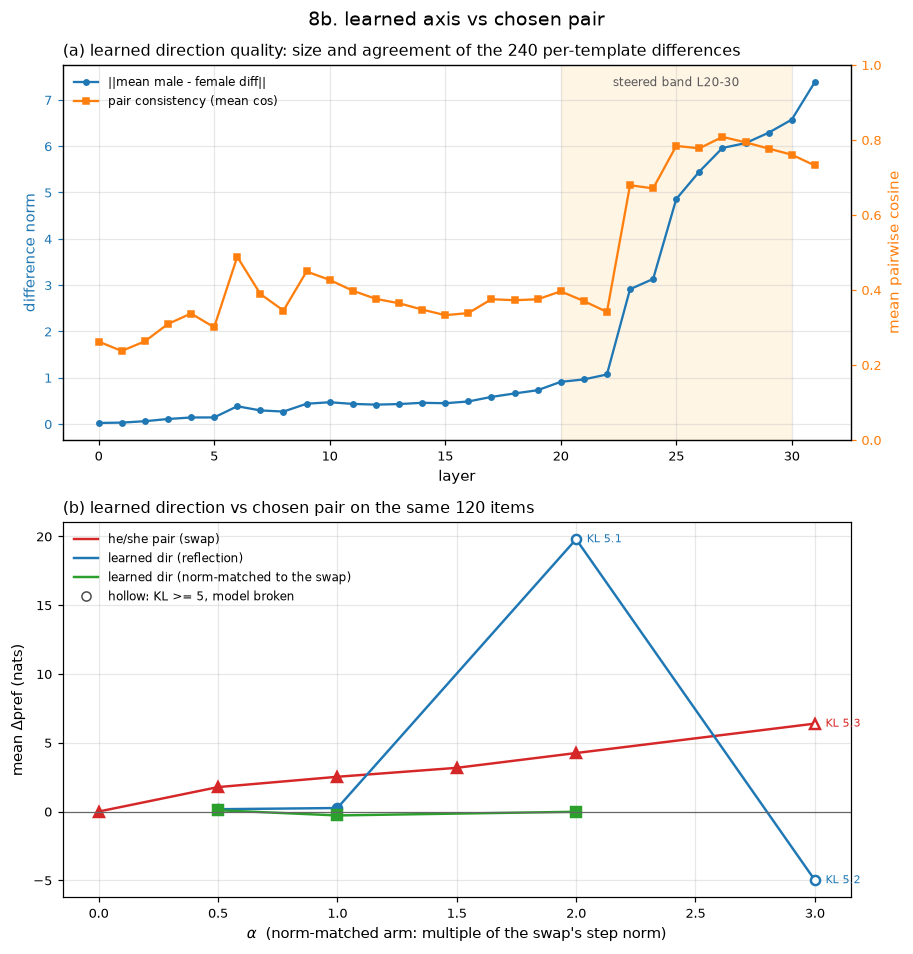

In [11]:
dd = fu.get("domdir")
if dd:
    print(f"8b. learned direction: band pair-cos "
          f"{dd['band_cos_mean']:+.3f} (min {dd['band_cos_min']:+.3f})")
    print("    reflection through the learned axis:")
    for a, v in (fu.get("domsteer") or {}).items():
        if v:
            print(f"      a={a}: delta-pref {v['d_pref']:+.2f}  "
                  f"flip {v['flip']:.0%}  KL {v['kl']:.3f}")
    dm = fu.get("dom_matched") or {}
    if dm:
        step = fu.get("dom_matched_step_norm")
        print(f"    same axis, step norm matched to the pair swap"
              f"{'' if step is None else f' ({step:.3f} per position)'}:")
        for a, v in dm.items():
            if v:
                print(f"      x{a}: delta-pref {v['d_pref']:+.2f}  "
                      f"flip {v['flip']:.0%}  KL {v['kl']:.3f}")
    bs_full = (fu.get("band_sweep") or {}).get("full L20-30") or {}
    ref = bs_full.get("1.0")
    if ref:
        print(f"    the token-pair swap at that same displacement (a=1): "
              f"delta-pref {ref['d_pref']:+.2f}  flip {ref['flip']:.0%}  "
              f"KL {ref['kl']:.3f}")
    print("    -> the learned axis is a consistent direction but a much worse")
    print("       handle on the pronoun slot at matched displacement; a=2+ for")
    print("       the reflection is past the fluency cliff (KL > 5), not a")
    print("       stronger intervention")

pair_stats = dose_stats(wg + read_jsonl(FU_DIR / "bandsweep.jsonl"))
dom_stats = dose_stats(read_jsonl(FU_DIR / "domsteer.jsonl")
                       + read_jsonl(FU_DIR / "dommatch.jsonl"))
KL_BROKEN = 5.0

if dd:
    layers_d = sorted(int(k) for k in dd["per_layer"])
    with plt.rc_context(RC8):
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(FIG_W, 2 * PANEL_H))
        a1.axvspan(20, 30, color=C8["band"], alpha=0.10, lw=0)
        a1.text(25, 0.97, "steered band L20-30", transform=a1.get_xaxis_transform(),
                ha="center", va="top", fontsize=8, color="0.35")
        a1.plot(layers_d, [dd["per_layer"][str(l)]["norm"] for l in layers_d],
                "-o", ms=3.5, color=C8["norm"], label="||mean male - female diff||")
        a1.set_ylabel("difference norm", color=C8["norm"])
        a1.tick_params(axis="y", colors=C8["norm"])
        a1b = a1.twinx()
        a1b.plot(layers_d, [dd["per_layer"][str(l)]["cos"] for l in layers_d],
                 "-s", ms=3.5, color=C8["cos"], label="pair consistency (mean cos)")
        a1b.set_ylim(0, 1)
        a1b.set_ylabel("mean pairwise cosine", color=C8["cos"])
        a1b.tick_params(axis="y", colors=C8["cos"])
        a1.set_xlabel("layer")
        a1.set_title("(a) learned direction quality: size and agreement of the "
                     "240 per-template differences")
        h1, l1 = a1.get_legend_handles_labels()
        h2, l2 = a1b.get_legend_handles_labels()
        a1.legend(h1 + h2, l1 + l2, loc="upper left")
        a1.grid(alpha=0.3)

        for arm, src, color, mk, lbl in (
                ("counter", pair_stats, C8["pair"], "^", "he/she pair (swap)"),
                ("dom", dom_stats, C8["learned"], "o", "learned dir (reflection)"),
                ("dom_matched", dom_stats, C8["matched"], "s",
                 "learned dir (norm-matched to the swap)")):
            xs = sorted(a for (k, a) in src if k == arm)
            ys = [src[(arm, a)]["d_pref"] for a in xs]
            a2.plot(xs, ys, "-", color=color, lw=1.6, label=lbl)
            for x, y in zip(xs, ys):
                broken = src[(arm, x)]["kl"] >= KL_BROKEN
                a2.plot(x, y, mk, ms=6, color=color,
                        mfc="white" if broken else color, mew=1.6)
                if broken:
                    a2.annotate(f"KL {src[(arm, x)]['kl']:.1f}", (x, y),
                                xytext=(7, -2), textcoords="offset points",
                                fontsize=7.5, color=color)
        a2.plot([], [], "o", ms=6, mfc="white", mec="0.3",
                label=f"hollow: KL >= {KL_BROKEN:g}, model broken")
        a2.axhline(0, color="0.4", lw=0.8)
        a2.set_xlabel(r"$\alpha$  (norm-matched arm: multiple of the swap's "
                      "step norm)")
        a2.set_ylabel(r"mean $\Delta$pref (nats)")
        a2.set_title("(b) learned direction vs chosen pair on the same 120 items")
        a2.legend(loc="upper left")
        a2.grid(alpha=0.3)
        fig.suptitle("8b. learned axis vs chosen pair")
        fig.tight_layout()
        plt.show()

### 8b. What the learned axis shows

The learned direction is the per-layer mean of the male-minus-female residual
difference over 240 Winogender minimal pairs, which differ only in the
pronoun. It is applied as a Householder reflection, so $\alpha = 1$ is already
the full reflection.

**Panel (a): the direction is real.** The blue line is the size of the mean
difference and the orange line is how well the 240 individual differences
agree (mean pairwise cosine). Both are low and flat through L0-L22 (norm under
1.1, cosine 0.24-0.49). Both jump at L23: the norm goes from 1.07 to 2.91 and
the cosine from 0.34 to 0.68. Across L25-L29 the cosine holds at 0.78-0.81 and
the norm keeps rising to 7.4 at L31. The band mean is +0.651, with a minimum
of +0.341 at L22. The 240 pairs agree on a direction, so
the arm passes its quality gate and the direction is not noise.

**Panel (b): the direction is a poor handle on the pronoun.** All three arms
act on the same 120 prompts. Hollow markers have KL of 5 or more: the model's
next-token distribution is wrecked, so those $\Delta$pref values are not a
bias effect.

- The chosen he/she pair (red) rises steadily: +1.78, +2.53, +3.18 and +4.25
  nats from $\alpha = 0.5$ to $\alpha = 2$, and breaks only at $\alpha = 3$
  (KL 5.3).
- The reflection (blue) gives +0.17 and +0.26 nats at $\alpha = 0.5$ and 1
  (8% and 32% flips). At $\alpha = 2$ and 3 it is past the cliff (KL 5.1 and
  5.2). The +19.8 spike and the -5.0 drop there are breakage, not steering.
- The norm-matched arm (green) moves along the learned direction by the same
  distance per position as the pair swap at $\alpha = 1$ (0.762). It stays
  flat at +0.10, -0.28 and -0.02 nats. Yet 20-42% of prompts flip: it pushes
  prompts in both directions and nets to about zero.

Per unit of side effect the pair swap gets about 13 nats of $\Delta$pref per
nat of KL at $\alpha = 1$. The reflection gets about 4.5, and the norm-matched
arm gets none. A direction that separates gendered contexts is not the same
object as the direction that moves the he and she logits. The
lens-transported pair is, by construction, the second one.

8c. random-direction null across seeds:
    s1_a1.0: delta-pref +0.10  KL 0.005
    s1_a2.0: delta-pref +0.19  KL 0.014
    s2_a1.0: delta-pref +0.05  KL 0.006
    s2_a2.0: delta-pref +0.12  KL 0.021
    s3_a1.0: delta-pref +0.02  KL 0.005
    s3_a2.0: delta-pref +0.05  KL 0.016
    s4_a1.0: delta-pref +0.00  KL 0.006
    s4_a2.0: delta-pref +0.01  KL 0.020
    s5_a1.0: delta-pref +0.02  KL 0.008
    s5_a2.0: delta-pref +0.02  KL 0.026
8d. generation-time steering (vignettes, decode-step hooks):
    arm / alpha: changed | pronoun counts differ | gender flipped | degenerate
     counter a=1.0: 6/10  |  1  |  1  |  1
     counter a=2.0: 10/10  |  10  |  1  |  10
        sham a=1.0: 5/10  |  1  |  0  |  1
        sham a=2.0: 10/10  |  1  |  0  |  10
    (text changing is not evidence by itself: the sham arm changes
     as many generations. alpha=2 degenerates in both arms - the
     counter arm babbles in pronouns, the sham arm in other tokens)


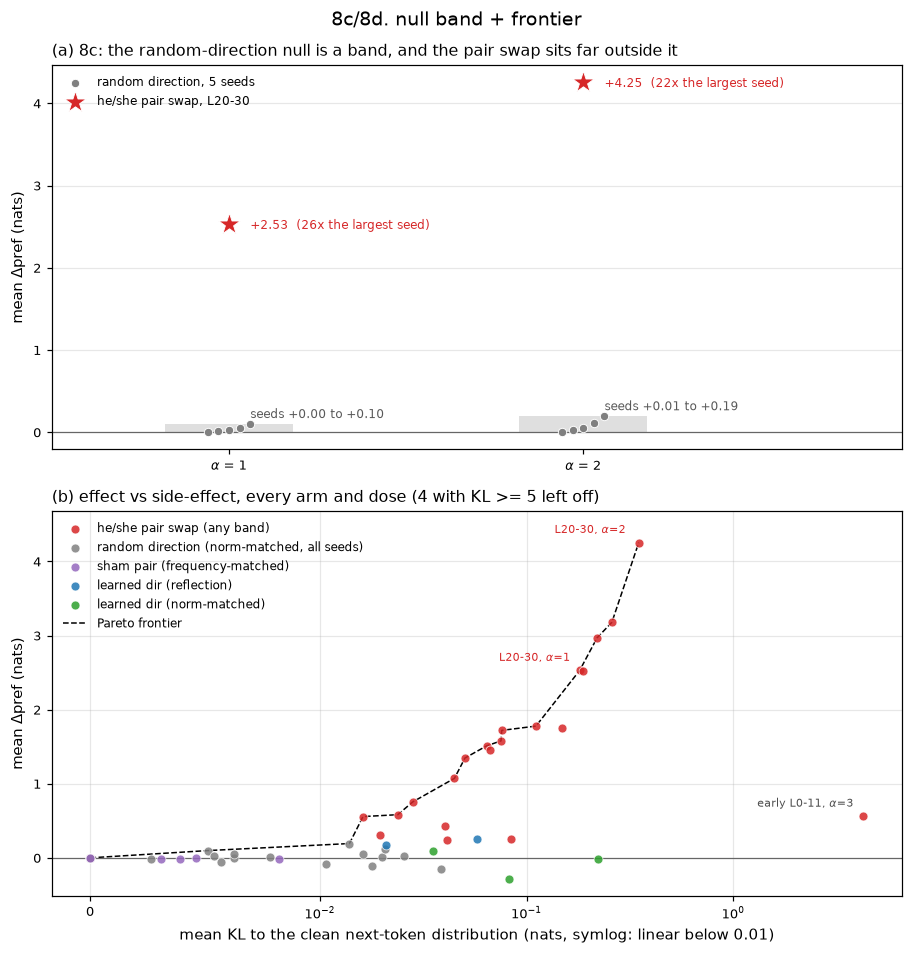

In [12]:
rs = fu.get("randseeds")
if rs:
    print("8c. random-direction null across seeds:")
    for k, v in sorted(rs.items()):
        print(f"    {k}: delta-pref {v['d_pref']:+.2f}  KL {v['kl']:.3f}")

gs = fu.get("gensteer")
if gs:
    print("8d. generation-time steering (vignettes, decode-step hooks):")
    print("    arm / alpha: changed | pronoun counts differ | gender flipped "
          "| degenerate")
    for t in gs:
        print(f"    {t['arm']:>8} a={t['alpha']}: {t['changed']}/{t['n']}"
              f"  |  {t.get('pronoun_changed', 0)}  |  "
              f"{t.get('gender_flipped', 0)}  |  {t.get('degenerate', 0)}")
    print("    (text changing is not evidence by itself: the sham arm changes")
    print("     as many generations. alpha=2 degenerates in both arms - the")
    print("     counter arm babbles in pronouns, the sham arm in other tokens)")

seed_stats = dose_stats(read_jsonl(FU_DIR / "randseeds.jsonl"))
all_stats = {**pair_stats, **seed_stats, **dom_stats}


def family(arm):
    if arm.startswith("counter"):
        return "pair"
    if arm == "dom":
        return "learned"
    if arm == "dom_matched":
        return "matched"
    return "sham" if arm == "sham" else "random"


FAMILY_LABEL = {"pair": "he/she pair swap (any band)",
                "learned": "learned dir (reflection)",
                "matched": "learned dir (norm-matched)",
                "sham": "sham pair (frequency-matched)",
                "random": "random direction (norm-matched, all seeds)"}

if rs:
    with plt.rc_context(RC8):
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(FIG_W, 2 * PANEL_H))

        jitter = np.linspace(-0.06, 0.06, 5)
        for x, a in enumerate((1.0, 2.0)):
            ys = sorted(v["d_pref"] for k, v in seed_stats.items() if k[1] == a)
            a1.fill_between([x - 0.18, x + 0.18], min(ys), max(ys),
                            color=C8["random"], alpha=0.25, lw=0)
            a1.scatter(x + jitter[:len(ys)], ys, s=30, color=C8["random"],
                       edgecolor="white", lw=0.6, zorder=3,
                       label="random direction, 5 seeds" if x == 0 else None)
            c = pair_stats.get(("counter", a))
            if c:
                a1.scatter([x], [c["d_pref"]], marker="*", s=220,
                           color=C8["pair"], edgecolor="white", lw=0.6, zorder=5,
                           label="he/she pair swap, L20-30" if x == 0 else None)
                a1.annotate(f"{c['d_pref']:+.2f}  ({c['d_pref'] / max(ys):.0f}x the "
                            f"largest seed)", (x, c["d_pref"]), xytext=(14, -3),
                            textcoords="offset points", fontsize=8,
                            color=C8["pair"])
            a1.annotate(f"seeds {min(ys):+.2f} to {max(ys):+.2f}", (x, max(ys)),
                        xytext=(14, 4), textcoords="offset points", fontsize=8,
                        color="0.35")
        a1.set_xticks([0, 1], [r"$\alpha$ = 1", r"$\alpha$ = 2"])
        a1.set_xlim(-0.5, 1.9)
        a1.axhline(0, color="0.4", lw=0.8)
        a1.set_ylabel(r"mean $\Delta$pref (nats)")
        a1.set_title("(a) 8c: the random-direction null is a band, and the pair "
                     "swap sits far outside it")
        a1.legend(loc="upper left")
        a1.grid(alpha=0.3, axis="y")

        pts = sorted((v["kl"], v["d_pref"], k[0], k[1])
                     for k, v in all_stats.items() if v["kl"] < KL_BROKEN)
        n_cut = sum(v["kl"] >= KL_BROKEN for v in all_stats.values())
        seen = set()
        for kl, d, arm, _a in pts:
            fam = family(arm)
            a2.scatter(kl, d, s=34, alpha=0.85, color=C8[fam],
                       edgecolor="white", lw=0.5, zorder=3,
                       label=None if fam in seen else FAMILY_LABEL[fam])
            seen.add(fam)
        best, fx, fy = -np.inf, [], []
        for kl, d, _, _ in pts:
            if d > best:
                best, fx, fy = d, [*fx, kl], [*fy, d]
        a2.plot(fx, fy, "k--", lw=1, label="Pareto frontier", zorder=2)
        for kl, d, arm, a in pts:
            if arm == "counter" and a in (1.0, 2.0):
                a2.annotate(rf"L20-30, $\alpha$={a:g}", (kl, d), xytext=(-8, 6),
                            textcoords="offset points", ha="right",
                            fontsize=7.5, color=C8["pair"])
            if kl > 1:
                name = "early L0-11" if arm == "counter_early" else arm
                a2.annotate(rf"{name}, $\alpha$={a:g}", (kl, d), xytext=(-6, 6),
                            textcoords="offset points", ha="right",
                            fontsize=7.5, color="0.3")
        # KL spans three decades; a linear axis piles every useful arm into one corner
        a2.set_xscale("symlog", linthresh=0.01)
        a2.axhline(0, color="0.4", lw=0.8)
        a2.set_ylim(top=1.1 * max(d for _, d, _, _ in pts))
        a2.set_xlabel("mean KL to the clean next-token distribution "
                      "(nats, symlog: linear below 0.01)")
        a2.set_ylabel(r"mean $\Delta$pref (nats)")
        a2.set_title(f"(b) effect vs side-effect, every arm and dose "
                     f"({n_cut} with KL >= {KL_BROKEN:g} left off)")
        a2.legend(loc="upper left")
        a2.grid(alpha=0.3)
        fig.suptitle("8c/8d. null band + frontier")
        fig.tight_layout()
        plt.show()

### 8c and 8d. What the null band, the frontier and the generation run show

**Panel (a), 8c: the random null is a narrow band.** Each grey dot is one
fresh random direction, norm-matched to the pair swap, on the same 120
prompts. The grey bar spans the five seeds. At $\alpha = 1$ the seeds give
+0.00 to +0.10 nats, flip at most 2.5% of prompts and have KL of 0.008 or
less. At $\alpha = 2$ they give +0.01 to +0.19, flip at most 5.8% and have KL
of 0.026 or less. The red star is the pair swap on L20-L30. It sits at +2.53
and +4.25, about 26 and 22 times the largest seed. The single random seed used
in section 3 gave -0.05 and -0.10, close to the same band. That control was
representative, not a lucky draw.

**Panel (b): effect against side effect for every arm and dose.** Each dot is
one arm at one $\alpha$. The horizontal axis is the mean KL to the clean
next-token distribution, and it is linear below 0.01 and logarithmic above.
The dashed line is the Pareto frontier: the largest $\Delta$pref reached at or
below each KL.

- **Only the pair swap reaches the frontier.** Above +0.2 nats every frontier
  point is a red pair-swap arm: the sub-bands at low dose, then the early band,
  then L29-L30 and the full band. The full band at $\alpha = 1$ ties with
  L29-L30 at $\alpha = 1$ (+2.53 at KL 0.188 against 0.181).
- **The controls stay flat at every cost.** The sham pair (purple) never moves
  more than 0.02 nats on the plot. The random directions (grey) stay within -0.15 to
  +0.19. The learned-axis arms (blue, green) stay below +0.26 while spending up
  to 0.22 nats of KL.
- **Over-driving is costly.** The early band at $\alpha = 3$ (lower right) pays
  KL 4.27 for +0.56 nats, less than it gets at $\alpha = 0.5$. Four arm-doses
  with KL of 5 or more are left off the plot: pair swap and sham at
  $\alpha = 3$, and the learned reflection at $\alpha = 2$ and 3.

**8d: steering during generation** (table above, no figure). The swap hook runs
at every decode step over 10 vignettes.

- At $\alpha = 1$ the pair swap changes 6 of 10 continuations and the sham pair
  changes 5. Text changing is therefore not evidence of steering by itself.
- Only the pair swap flips a pronoun's gender, in 1 of 10 continuations. In
  the software-engineer vignette "but he is not a good person" becomes "but
  she is not a good person", and the next sentence adds "The engineer, who is a
  woman". The sham pair flips none. With 10 vignettes, 1 against 0 is a single
  example, not a rate.
- At $\alpha = 2$ both arms degenerate in 10 of 10 continuations. The failure
  follows the axis: the pair swap loops on pronouns ("she he she he ...") and
  changes pronoun counts in 10 of 10, while the sham pair loops on other
  tokens ("series first first ...") and changes them in 1 of 10.

Panel (b) explains the narrow window. The frontier measures a single
next-token prediction, where $\alpha = 2$ costs only 0.35 nats of KL. Generation applies the
edit at every step, so the cost compounds, and that dose is already enough to
derail every continuation. The usable dose at decode time is near
$\alpha = 1$. At that dose the edit changes a pronoun when the text reaches
one, but it does not rewrite the gender of the story.

## 9. Findings

**F1. The ported two-pass lens swap passes its validation gate, and the gate
caught a real bug first.** The reference design exchanges two coordinates in
the basis `V = [v_source, v_target]`, where each `v` is a token's unembedding
row pulled through the per-layer Jacobian. My first port silently did nothing
(KL exactly 0 at every alpha) because the hook used the cached *clean*
coordinates as the target instead of their flip; the alpha = 0 identity check
plus the Paris -> Beijing control caught it before any bias claim was made.
After the fix: alpha = 0 is exactly the identity (max KL 0.00 over 4 runs),
and the factual swap flips ` Paris` -> ` Beijing` (KL 6.19) and ` Paris` ->
` Tokyo` (KL 8.59) already at alpha = 0.5.

**F2. The pronoun swap controls the Winogender cloze slot, with a clean
monotone dose-response, and neither control arm moves.** Delta pref
(logP(she) - logP(he), clean baseline -1.237 nats on average), counter arm
L20-L30: +1.78 at alpha 0.5, +2.53 at 1.0, +3.18 at 1.5, +4.25 at 2.0, with
the sign of the preference flipping in 85-96% of the 120 templates and
distributional cost of only 0.11-0.35 nats KL. The frequency-matched sham
pair (` first`/` series`, matched to within 0.085-0.70 nats of wikitext
unigram log-frequency) and norm-matched random directions both stay within
0.02-0.15 nats of zero at every alpha up to 2. This is the causal claim the
detection correlation cannot make on its own: the `he`/`she` coordinates in
the band are not decorative, they set the slot.

**F3. The swap does not remove the BLS association, it reverses it.** The
steered readout's correlation with BLS percent-female goes from +0.789 clean
to -0.69 (alpha 0.5) and -0.59 (alpha 2.0). Coordinate exchange inverts the
sign of the gender expectation rather than neutralising it, which is what the
linear picture predicts but worth seeing measured. There is no alpha at which
the readout is decorrelated from BLS without being anti-correlated.

**F4. The same intervention barely moves the BBQ multiple-choice gap, so the
cloze result does not transfer across formats.** On 200 polarity-balanced BBQ
items (Gender_identity + Age, the two strongest Week 2 categories), scoring
the option letters with the Week 2 estimator: the largest effect at any safe
dose is +0.035 (95% CI +0.01 to +0.06, Gender_identity disambiguated, alpha
2.0) in log10(1+rank) units, and every pre-disambiguation-window variant is
null (all CIs cross zero, |delta| <= 0.02). For scale, the detection gap the
intervention would need to explain is about 0.09 in the same units. The axis
that fully controls a pronoun cloze does not control the multiple-choice
answer - the two formats surface the stereotype through different mechanisms.

**F5. Band specificity is real but partial.** The early-band arm (L0-L11)
moves the same slot in the same direction, at about half to two thirds the
magnitude (delta +1.35 to +1.72, flips 53-76%, versus +1.78 to +4.25 and
85-96% for L20-L30) and lower KL. Gender coordinates are not confined to the
Week 2 bias band; the band is where they are strongest, not the only place
they exist. On the factual France control, both bands flip the answer, so the
band distinction should not be over-read.

**F6. Alpha = 3 is a broken regime, and the brokenness is detectable without
domain knowledge.** At alpha 3 the counter arm's KL jumps to 5.3 nats, the
sham arm - which does nothing at alpha <= 2 - suddenly moves the pronoun
preference by +3.2 nats with 77.5% flips, and held-out wikitext NLL goes from
2.78 to 12.7 (counter) and 40.1 (sham). Any effect measured only at alpha 3 is
a symptom of general damage, not axis-specific steering; the sham arm and the
fluency probe are what make that visible. Usable doses for this axis are
alpha <= 2.

**F7. Collateral cost at usable doses is small but nonzero.** Held-out
wikitext next-token NLL rises from 2.780 by +0.140 (alpha 1) and +0.173
(alpha 2) for the counter arm, i.e. a perplexity ratio of 1.15-1.19; the sham
arm costs about a third of that (+0.038 / +0.065). Cost and effect both scale
with alpha, and the counter arm costs roughly 3x the sham for the effect of
fully reversing the slot.

**F8. Free-generation vignettes show the slot-level effect does not become a
story-level reversal.** Under counter-steering at alpha 1-2, most of the 11
greedy continuations change only in their trailing text or not at all. The
model already resolves the classic surgeon riddle counter-stereotypically
without any intervention ("the child's mother" in the clean run), so that
vignette demonstrates nothing about the swap. Where the continuation does
change, the change is gendered in the predicted direction - "The CEO cancelled
the meeting because" completes "the client was not available" clean versus
"she was busy" steered. These 11 single-sample generations are illustrative
only: the coordinate exchange clearly governs a pronoun slot (F2), but one
swap at one position does not rewrite the gendered framing of a whole
generated passage.

**F9. Honest negative results worth stating plainly.** (a) The
pre-disambiguation window intervention - the specific causal story that would
connect the Week 2 mid-stack lens gap to the answer - produced nothing at any
safe dose, in either category. (b) On the France control the early band
performs as well as the bias band, so band choice is not validated by the
gate, only by the relative magnitude in F5. (c) The steering axis is a
two-token unembedding difference pulled through J; a learned
difference-of-means direction over many gendered contexts is the natural
stronger axis and is left as future work.

**F10. The causal locus is the top of the band, and it dissociates from the
correlational peak.** Sweeping sub-bands at matched dose, L29-L30 alone
reproduces the entire eleven-layer effect: +2.53 nats and 94% flips at
alpha = 1, against +2.53 and 96% for the full L20-L30. The mid-band, where the
Week 2 correlational signal peaked, is nearly inert - L20-L22 gives +0.58
(15% flips) and L23-L25 gives +0.43 (20%) - with L26-L28 intermediate at +1.07
(39%). Where the pronoun choice can be *changed* is therefore not where the
lens gap is largest. The early band remains a genuine caveat: L0-L11 still
yields +1.51 nats and 64% flips at the lowest divergence of any arm
(KL = 0.064), so an edit on this axis propagates from almost anywhere upstream
and band choice is not privileged by the causal test either.

**F11. The learned difference-of-means axis is a real direction and a bad
intervention - the F9(c) expectation is refuted.** Estimated from 240 minimal
pairs, the direction is internally consistent (mean pair-cosine +0.651 across
the band, +0.78 at L26-L29, rising from +0.26 at L0), so it is not noise. But
steering along it fails on two comparisons. As a reflection it gives +0.26
nats and 32% flips at alpha = 1 (KL 0.058) against the token-pair swap's +2.53
and 96% (KL 0.188); alpha >= 2 is over-driven by construction, since alpha = 1
is already the full reflection, and lands in the broken regime (KL 5.1, so the
+19.8 nats there is not a bias effect). Matched properly - same mean
displacement norm as the swap at alpha = 1, 0.762 per position - it gives
-0.28 nats with 27% of items flipping, i.e. it moves items in both directions
and nets to nothing on the he/she contrast. The lens-transported unembedding
pair wins because it is by construction the direction that moves those two
logits; a direction that merely separates gendered contexts is not the same
object.

**F12. The random-direction null is a distribution, not one lucky draw.** Five
fresh seeds at matched norm span +0.00 to +0.10 nats at alpha = 1 and +0.01 to
+0.19 at alpha = 2, with at most 6% of items flipping and KL <= 0.026. The
counter arm sits 13-20x outside that band, so the single-seed control in F4
was representative.

**F13. Steering during generation does change pronouns, and only the counter
arm does so.** Hooking every decode step over 10 vignettes at alpha = 1
changes 6/10 counter continuations and 5/10 sham ones - text churn alone is
not evidence - but only the counter arm flips a continuation's pronoun gender
(1/10, the software-engineer vignette's "but he is not a good person" becoming
"she"), against 0/10 for sham. At alpha = 2 both arms degenerate into
repetition (10/10), and the failure mode is axis-specific: the counter arm
babbles in pronouns while the sham arm babbles in other tokens. So the
intervention governs a pronoun slot when generation reaches one, it does not
rewrite narrative gender (consistent with the corrected F8), and the usable
dose window at decode time is narrow.


## 10. Limitations

- **The coordinate exchange is exact in the transported basis, not in logit
  space.** An RMS norm sits between the residual stream and the unembedding, so
  forcing `V^+ h` to a target value does not force the corresponding logits to
  that value. This is the reference implementation's design; section 1
  validates it empirically rather than assuming it.
- **The pair was chosen, not learned - addressed in section 8b.** The learned
  difference-of-means direction is compared against the ` he` / ` she` pair
  there. The two interventions are not identically parameterised (coordinate
  exchange vs Householder reflection), so the comparison is of effect size
  per KL, not of exact semantics.
- **Band specificity is partial; section 8a sharpens it.** The sub-band sweep
  localises the effect inside L20-30.
- **`sham` is matched on frequency, `random` on norm, neither on both.** The
  two arms bracket the confound rather than eliminating it in a single
  control.
- **Prompt-position steering - complemented in section 8d**, where the hook
  stays active at every decode step. Generation-time steering flips
  coordinates computed on the fly, so it is a slightly stronger intervention
  than the prefill version, not the same one measured later.
- **One model, one lens; the random null is now a distribution** (5 fresh
  seeds, section 8c) rather than the single draw of the first round.
- **The BBQ arm uses `he`/`she` while the answer options are noun phrases.**
  The intervention therefore acts on a pronoun axis and is read out on option
  letters; a mismatch that plausibly weakens the measured effect.
- **int8 throughout,** as in Week 2, with the fidelity check reported in the
  detection notebook.


## 11. Reproducing this

**Just re-running the notebook (no GPU).** Everything above is computed from
`cataluna84_week_3_data/input` and `cataluna84_week_3_data/output` beside this
file: about 2.7 MB of gzipped run artifacts, no model download. Clone the
repo, open the notebook from `Week 3/submissions/`, and Run All. On Colab,
open the notebook on its own and Run All anyway: the first cell sparse-clones
just that folder into `/content`. To point it elsewhere, set
`W3_BUNDLE=<folder holding input/ and output/>`.

**Regenerating the artifacts from scratch** needs a ~9 GB GPU and about 4 h:

```bash
# 1. frequency-matched sham pair from wikitext (the lens's own fitting corpus)
python analysis/week3_steering.py freq --pair " he, she"

# 2. gate: reproduce the reference swap and check alpha = 0 is the identity
python analysis/week3_steering.py validate --alphas 0,1,1.5,2

# 3. dose-response, causal test, costs
python analysis/week3_steering.py winogender
python analysis/week3_steering.py bbq --categories Gender_identity,Age \
    --blocks-per-cat 25 --alphas 0,1,2,3 --arms counter,sham
python analysis/week3_steering.py fluency --limit 40 --alphas 0,1,2,3 \
    --arms counter,sham
python analysis/week3_steering.py vignettes --alphas 1,2 --arms counter
python analysis/week3_steering.py summarize

# 4. follow-up round (section 8)
python analysis/week3_followups.py domdir      # learned direction
python analysis/week3_followups.py domsteer --alphas 0.5,1,2,3
python analysis/week3_followups.py dommatch --alphas 0.5,1,2   # norm-matched
python analysis/week3_followups.py bandsweep --alphas 0.5,1,2
python analysis/week3_followups.py randseeds --alphas 1,2
python analysis/week3_followups.py gensteer --alphas 1,2
python analysis/week3_followups.py summarize
```

The companion scripts `cataluna84_week_3_steering.py` and
`cataluna84_week_3_followups.py` in this directory are the exact
`analysis/week3_steering.py` / `analysis/week3_followups.py` used for the
runs. The mechanism is a port of `vector-swapping.ipynb` from this
repository.
